In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [2]:
class Perceptron:
    def __init__(self, learning_rate=0.01, n_iterations=100):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = 0
        self.errors = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0
        self.errors = []

        for _ in range(self.n_iterations):
            errors = 0

            for xi, target in zip(X, y):
                linear_output = np.dot(xi, self.weights) + self.bias
                prediction = 1 if self.sigmoid(linear_output) >= 0.5 else -1

                update = self.learning_rate * (target - prediction)

                self.weights += update * xi
                self.bias += update

                if update != 0:
                    errors += 1

            self.errors.append(errors)

        return self

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        probabilities = self.sigmoid(linear_output)

        return np.where(probabilities >= 0.5, 1, -1)

In [3]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

# Select only two classes
mask = y < 2

X = X[mask]
y = y[mask]

# Convert labels to -1 and +1
y = np.where(y == 0, 1, -1)

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (100, 4)
Output shape: (100,)


In [11]:
# map the labels to a binary integer value
y = np.where(y == 'Iris-setsa', 1, -1)


In [12]:
X = (X - X.mean(axis=0)) / X.std(axis=0)

print("Standardized data:")
print(X[:5])

Standardized data:
[[-0.5810659   0.84183714 -1.01297765 -1.04211089]
 [-0.89430898 -0.2078351  -1.01297765 -1.04211089]
 [-1.20755205  0.21203379 -1.08231219 -1.04211089]
 [-1.36417359  0.00209934 -0.94364311 -1.04211089]
 [-0.73768744  1.05177159 -1.01297765 -1.04211089]]


In [13]:
# split the data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))



Training samples: 80
Testing samples: 20


In [14]:
model = Perceptron(
    learning_rate=0.01,
    n_iterations=100
)

model.fit(X_train, y_train)

print("Training completed!")

Training completed!


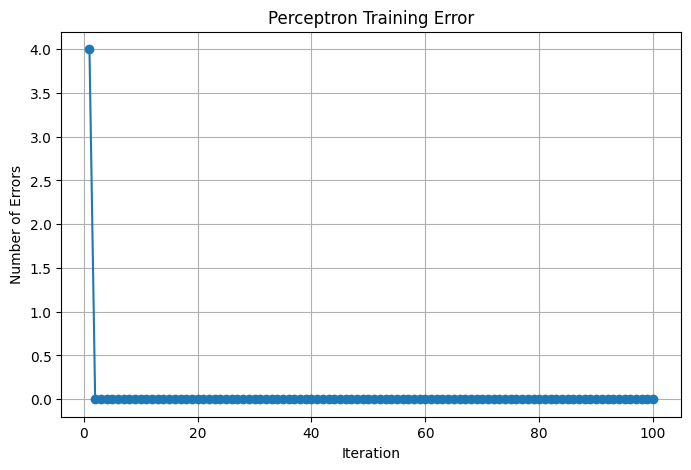

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(model.errors) + 1),
    model.errors,
    marker='o'
)

plt.xlabel("Iteration")
plt.ylabel("Number of Errors")
plt.title("Perceptron Training Error")
plt.grid(True)

plt.show()

In [19]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Name: Rithika K")
print("Reg No:212224230230")

print("Predicted values:")
print(y_pred)

print("\nActual values:")
print(y_test)

print("\nAccuracy:", accuracy * 100, "%")

Name: Rithika K
Reg No:212224230230
Predicted values:
[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]

Actual values:
[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]

Accuracy: 100.0 %
